# Conditional alphas {#sec-alphas}

Now we need to get the conditional alphas from the risk-adjusted returns and state variables.

The following math and commentary are taken largely as-is from the paper. First, I present the theory, then the implementation in Python, and finally the results.

## Methodology

The methodology is taken from @Distaso2013, section 2.2.

In [src/betas.ipynb](src/betas.ipynb) (@sec-betas), we calculated the risk-adjusted returns $\hat{Z}_{i, t+1, M}$. This is useful because $Z_{i,t+1} = \alpha_{i,t} + \epsilon_{i,t+1} + \eta_{i,t+1}$. Identification of the conditional alpha stems from the fact that the conditional expectations of $\epsilon_{i,t+1}$ and $\eta_{i,t+1}$ are zero, so that $\alpha_{i,t} \equiv \mathbb{E}(Z_{i,t+1}|C_t)$.

Thus, it suffices to estimate the conditional expectation of the risk-adjusted returns, $\mathbb{E}(Z_{i,t+1}|C_t)$, to back out conditional alphas.

After estimating $\hat{Z}_{i, t+1, M}$ with the realized betas, we only need to estimate the conditional expectation $\mathbb{E}(\hat{Z}_{i,t+1,M}|C_t)$ of the realized risk-adjusted returns using nonparametric kernel methods. The paper proposes a consistent estimator with respect to the number of intraday observations $M$.

The high dimensionality of the state variable vector $C_t$ clashes with the nonparametric kernel estimator convergence, so we need to summarize it with PCA. Let then $\widehat{PC}_t = (\widehat{PC}_{1,t}, \dots, \widehat{PC}_{k,t})'$ denote the $k \le k_C$ principal component estimates of $C_t$.

The conditional alpha estimator is:

$$
\hat{\alpha}_{i,t} = \hat{m}_{i,T,M}(\widehat{PC}_t) = \frac{\frac{1}{T h_T^k} \sum_{\ell=1}^{T-1} \hat{Z}_{i,\ell+1,M} K\left(\frac{\widehat{PC}_\ell - \widehat{PC}_t}{h_T}\right)}{\hat{g}_T(\widehat{PC}_t)}
$$

<!-- TODO: tag(9) -->

where $\hat{g}_T(\widehat{PC}_t) = \frac{1}{T h_T^k} \sum_{\ell=1}^{T-1} K\left(\frac{\widehat{PC}_\ell - \widehat{PC}_t}{h_T}\right)$ is the kernel estimator of the density $g$ of the vector of principal components. 

To circumvent the difficulty of estimating $m_i(pc)$ over regions of low density, we consider a trimmed version of $\hat{m}_{i,T,M}(pc)$ as in Andrews (1995):

$$
tr_T\{\hat{m}_{i,T,M}(pc)\} = \hat{m}_{i,T,M}(pc) 1\{pc \in \hat{G}_T(pc)\}
$$

where $\hat{G}_T(pc) = \{c : \hat{g}_T(pc) > d_T\}$.

Other trimming strategies will be considered, such as $h_t^{0.25} / \ln(t)^2$.

<!-- Instead of trimming, one could gauge the magnitude of the conditional alphas relative to the noise level by means of Treynor and Black's (1973) appraisal ratio, which gauges the extra units of unsystematic risk investors have to bear for deviating from a passive management strategy. We explore this alternative in Appendix B.2. -->

### Expanding window calculation

The paper proposes an expanding window to restrict attention to real-time information:

> To obtain conditional alphas, we entertain an expanding window to restrict attention to real-time information. We estimate the conditional expectation of the risk-adjusted returns using either an affine specification or a kernel-regression approach using a multivariate standard Gaussian kernel with rule-of-thumb bandwidths. As for the amount of trimming in (10), uniform consistency requires $d_T = O(h_T^\zeta)$ with $0 < \zeta < 1/4$. Note that, because $h_T \to 0$ as $T \to \infty$, trimming becomes more aggressive as $\zeta$ declines. We set $\zeta$ to 0.20 to enforce only a mild trimming, though we also experiment with other values of $\zeta$ in Section 4.2.

This windowed version calculates $\widehat{PC}_t$ using data from $1:t$ only. And the bandwidth $h_T$ and trimming threshold $d_T$ are calculated separately for each $t$ using $t$ as $T$. Additionally, the kernel estimator does not use data up to $T$, but only up to $t-1$. To differentiate the notation, let $W = t$ be the total window size:

$$
\hat{\alpha}_{i,t} = \hat{m}_{i,W,M}(\widehat{PC}_t) = \frac{\frac{1}{W h_W^k} \sum_{\ell=1}^{W-1} \hat{Z}_{i,\ell+1,M} K\left(\frac{\widehat{PC}_\ell - \widehat{PC}_t}{h_W}\right)}{\hat{g}_W(\widehat{PC}_t)}
$$

<!-- CHECK: should it be fixed h_T and d_T still? -->

### Gaussian Kernel

For a single real-valued standardized deviation $u \in \mathbb{R}$, the standard univariate 1D Gaussian kernel function $K(u)$ is defined as the standard normal probability density function:

$$
K(u) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{1}{2} u^2 \right)
$$

In our nonparametric setting, for a single feature $j$ at time $\ell$ evaluated at time $t$, $u_{\ell, j} = \frac{\widehat{PC}_{\ell, j} - \widehat{PC}_{t, j}}{h_W}$.

As established in Assumption _A(iv)_ of the paper, the $k$-dimensional joint kernel $K(u)$ across $k$ independent principal components $u = (u_1, u_2, \dots, u_k)'$ is constructed as a product kernel of $k$ univariate Gaussian kernels:

$$
K(u) = \prod_{j=1}^{k} K(u_j) = \prod_{j=1}^{k} \left[ \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{1}{2} u_j^2 \right) \right]
$$

By factoring out the constant coefficient and applying the exponent product rule $\prod_{j=1}^{k} e^{a_j} = e^{\sum_{j=1}^{k} a_j}$, the joint kernel simplifies to:

$$
K(u) = \left( \frac{1}{\sqrt{2\pi}} \right)^k \prod_{j=1}^{k} \exp\left( -\frac{1}{2} u_j^2 \right) = \left( \frac{1}{\sqrt{2\pi}} \right)^k \exp\left( -\frac{1}{2} \sum_{j=1}^{k} u_j^2 \right)
$$


## The data

> The daily frequency of the analysis dictates the choice of state variables. In particular, we consider changes in the VIX index and in the Fed Fund rate, credit and term spreads, momentum, size and value factors, short- and long-term reversal factors, and volatility risk premium (namely, difference between the VIX index and realized volatility). To avoid the curse of dimensionality, we consider only their three first principal components.

The data is stored in `data/states_raw/FactorData_2018.mat`, where the "factors" key has a dataset of several state variables, and the "ADSdata" has many columns of the same variable, ending at different dates, with each column being used for the window that ends at the same date.

## The algorithm

Similar to before, the operations are independent between stocks, so the main loop is a parallelized loop over stocks.

Calculating the PC and kernel bandwidths and trimming thresholds is done separately for each stock, considering only the state variable periods that match the stock's trading days. This is considered more appropriate than calculating the PC and bandwidths outside the stock loop, but it is more computationally expensive.

This is the most expensive part of the whole project and could be optimized especially with numba or Cython in the innermost functions (e.g. PCA and kernel density estimation).

The main algorithm sets up the stock and state variables data and runs the following procedure for each stock, once for 1-minute data and once for 5-minute data:

```pascal
// Parameters:
k = 3 // Number of principal components to use
scaler = 1 // Bandwidth scaling factor
trim_exp = 0.20 // Trimming exponent
trim_scaler = 1 // Trimming scaling factor

procedure get_permno_alphas(
    permno : Integer;
    data_permnos : DataFrame; // Stock adjusted returns
    f : Matrix;               // "factors"
    ads : Matrix;             // "ADSdata"
);
    // 1. Data Alignment
    Z_data = query permno from data_permnos;
    intersect timestamps to align Z_data, f, and ads;
    
    Z_1_T, f_1_T, ads_1_t = aligned data; // Shape: (T,)
    
    T = length of Z_1_T;
    Initialize res_ts, res_alpha, res_linear of size (T - warmup);

    // 2. Expanding window loop (restricting to real-time information)
    for w = warmup to T do
    begin
        wi = w - warmup;
        res_ts[wi] = timestamp at w - 1;
        W = w; // Current window size

        // Extract windowed state variables
        ads_1_w = ads_1_t column with data up to w // Shape: (W, 1)
        C_1_W = concatenated f_1_T[1:W, :], ads_1_w  // Shape: (W, F)

        // --- Dimensionality Reduction (PCA) ---
        C_norm = standardize(C_1_W); // Shape: (W, F)
        eigvecs = eigen decomposition of cov(C_norm), sorted by descending eigenvalues;
        PC_1_W = (C_norm * eigvecs[:, 1:k]) / 100.0; // Shape: (W, k)
        PC_1_W = standardize(PC_1_W);                 // Shape: (W, k)

        // --- Nonparametric bandwidth & thresholds ---
        bandrate = (4 / (k + 2)) ** (1 / (k + 4)) * (W ^ (- 1 / (k + 4)));
        h_W = scaler * bandrate; // Kernel bandwidth
        d_W = (bandrate ^ trim_exp) * trim_scaler; // Trimming threshold

        // --- Split current state vs historical states & targets ---
        PC_W = PC_1_W[W, :];               // Shape: (k,) | Conditioning state at time W
        PC_1_Wm1 = PC_1_W[1:W-1, :];      // Shape: (W-1, k) | Historical state variables
        Z_2_W = Z_1_T[2:W];               // Shape: (W-1,) | Target risk-adjusted returns

        // --- Linear Conditional Alpha ---
        res_linear[wi] = fitted value of PC_W from OLS regression of Z_2_W on PC_1_Wm1;

        // --- Nonparametric Conditional Alpha (Nadaraya-Watson with Trimming) ---
        // Evaluate multivariate Gaussian kernel across the k dimensions for historical distances
        K_x = gaussian_kernel((PC_1_Wm1 - PC_W) / h_W) / (h_W ** k); // Shape: (W-1,)
        
        density = mean(K_x); // Kernel density estimator evaluated at PC_W
        
        // Trim alpha to 0.0 in regions of low state variable density (Andrews 1995)
        if density <= d_W then
            res_alpha[wi] = 0.0;
        else
            res_alpha[wi] = mean(K_x * Z_2_W) / density;
    end;

    return (permno, res_ts, res_alpha, res_linear);
end;
```

## Code setup

Core modules:

In [2]:
#| output: false
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import numpy as np
import polars as pl

from pickle import dump
from scipy.io import loadmat, savemat
from h5py import File
from tqdm import tqdm

from typing import NamedTuple, Final
from numpy.typing import NDArray

import src.utils as ut
import src.graphs as plot
from src.parameters import PARAMETERS as PARS

class sio:
    loadmat = staticmethod(loadmat)
    savemat = staticmethod(savemat)

class h5py:
    File = staticmethod(File)

class pkl:
    dump = staticmethod(dump)

Parameters:

In [ ]:
class AlphasParameters(NamedTuple):
    window_warmup: int # Initial burn-in window size
    #scaler: float      # Bandwidth scaling factor
    trim_exp: float    # Trimming exponent zeta in (0, 1/4)
    trim_scaler: float # Trimming density threshold scaling factor
    k: int             # Number of principal components to retain

PARS_ALPHAS: Final[AlphasParameters] = AlphasParameters(
    window_warmup = 500,
    #scaler = 1,      # Try 0.5, 1, 2, 3.5
    trim_exp = 0.25,  # Bounded by (0, 1/4)
    trim_scaler = 1, # 1 to turn on 0 to turn off
    k = 3
)

k = PARS_ALPHAS.k

DATE_START, DATE_END = (
    pl.lit(x.astype("datetime64[D]").astype(np.uint32))
    for x in [np.datetime64("2001-01-01 00:00:00", "m"), np.datetime64("2017-12-29 23:59:59", "m")]
)


## Data validation

The paper states the following data sources:

> The daily frequency of the analysis dictates the choice of state variables. In particular, we consider changes in the VIX index and in the Fed Fund rate, credit and term spreads, momentum, size and value factors, short- and long-term reversal factors, and volatility risk premium (namely, difference between the VIX index and realized volatility). We gather the Fama-French, momentum and reversal factors from Kenneth French's webpage at http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html. Interest rates are from the FRED database, whereas the VIX index is from the Chicago Board Options Exchange. To avoid the curse of dimensionality, we consider only their three first principal components.

This data was saved into the MATLAB data file `data/states_raw/FactorData_2018.mat`.

The timestamp variables seem to be days from epoch `0000-01-01`. MATLAB has 1-indexing for days, so we need to subtract `719_529` to align with the epoch `1970-01-01` being used in Python.

In [ ]:
def load_state_data(path: str) -> pl.DataFrame:
    state_mat = sio.loadmat(path)

    state_raws = []
    for key in ["factors", "ADSdata"]:
        mat = state_mat[key]
        data = (
            pl.DataFrame(mat[:, 1:])
            .with_columns(ts_day_ny = (mat[:, 0] - 719_529).astype(np.uint32))
            .select(pl.col("ts_day_ny"), pl.all().exclude("ts_day_ny"))
        )
        state_raws.append(data)

    data_state = (
        state_raws[0]
        .join(state_raws[1], on = "ts_day_ny", how = "inner")
        .filter(
            (pl.col("ts_day_ny") >= DATE_START)
            & (pl.col("ts_day_ny") <= DATE_END)
        )
        .with_columns(pl.all().fill_nan(None))
        .pipe(lambda df:
            df.select(
                col for col in df.columns
                if not (df[col].is_null().any() or df[col].is_nan().any())
            )
        )
        .tail(-1) # To match with adjusted returns' dropped 1st observation
    )

    return data_state

data_state = load_state_data("data/states_raw/FactorData_2018.mat")

A first look at the data is as below. Note that it has different levels of decimal precision, something that comes from the different sources.

In [5]:
with pl.Config(tbl_cols = 7):
    display(data_state)

ts_day_ny,column_0,column_1,…,column_894,column_895,column_896
u32,f64,f64,…,f64,f64,f64
11325,-3.39,-0.32,…,-0.790969,-0.790969,-0.790969
11326,0.37,-0.43,…,-0.808035,-0.808035,-0.808035
11327,1.7,-0.09,…,-0.825037,-0.825037,-0.825037
11330,1.17,0.15,…,-0.875067,-0.875067,-0.875067
11331,-1.85,-0.03,…,-0.891353,-0.891353,-0.891353
…,…,…,…,…,…,…
17522,0.28,0.0,…,-0.04509,-0.04509,-0.045083
17526,0.35,0.0,…,-0.105166,-0.105166,-0.105156
17527,0.22,0.0,…,-0.120432,-0.120432,-0.120422


Returns loading:

In [6]:
data_adjusted = pl.scan_parquet("data/stocks_1min_adjusted.parquet")

The state variables dataset must be validated:

- The date ranges in both datasets should be the same. Ideally both date vectors should be identical, but it is not a problem if not.
- There should be no duplicate values in the date vectors.
- There should be no nulls or NaNs in the data.
- All variables should be float64.

In [7]:
range_states = tuple(f(data_state["ts_day_ny"]) for f in [min, max])

range_returns = (
    data_adjusted
    .select(
        min = pl.col("ts_day_ny").min(),
        max = pl.col("ts_day_ny").max()
    )
    .collect()
    .row(0)
)

if range_states != range_returns:
    raise ValueError(
        f"State and returns data have different date ranges: "
        f"{range_states} vs {range_returns}"
    )

Some days are only present in the state variables or in the returns data. While it would be ideal to not have that, it is not a problem to drop them.

In [8]:
days_state = pl.from_epoch(data_state["ts_day_ny"], "d").to_numpy()

days_only_state = ~ np.isin(days_state, PARS.trading_days_final)
print(
    f"{np.sum(days_only_state)} days in state but not in returns:",
    ut.format_days_byyear(days_state[days_only_state])
)

days_only_returns = ~ np.isin(PARS.trading_days_final, days_state)
print(
    f"\n{np.sum(days_only_returns)} days in returns but not in state:",
    ut.format_days_byyear(PARS.trading_days_final[days_only_returns])
)

49 days in state but not in returns: 
- 2001: 06-08, 07-03, 11-23, 
- 2002: 07-05, 09-11, 11-29, 12-24, 
- 2003: 07-03, 08-15, 11-28, 12-24, 12-26, 
- 2004: 11-26, 
- 2005: 11-25, 12-23, 
- 2006: 07-03, 11-24, 
- 2007: 07-03, 11-23, 12-24, 
- 2008: 07-03, 11-28, 12-24, 12-26, 
- 2009: 11-27, 12-24, 
- 2010: 11-26, 12-27, 
- 2011: 08-15, 11-25, 12-23, 12-27, 
- 2012: 07-03, 11-23, 12-24, 
- 2013: 07-03, 08-22, 11-29, 12-24, 
- 2014: 07-03, 11-28, 12-24, 12-26, 
- 2015: 11-27, 12-24, 
- 2016: 11-25, 12-23, 
- 2017: 07-03, 11-24, 

40 days in returns but not in state: 
- 2001: 01-02, 03-08, 03-21, 10-08, 11-12, 
- 2002: 10-14, 10-31, 11-11, 
- 2003: 01-17, 01-21, 10-13, 11-11, 
- 2004: 01-12, 01-13, 10-11, 10-12, 11-11, 
- 2005: 10-10, 11-11, 
- 2006: 10-09, 
- 2007: 10-08, 11-12, 
- 2008: 10-13, 11-11, 
- 2009: 10-12, 11-11, 
- 2010: 10-11, 11-11, 
- 2011: 10-10, 11-11, 
- 2012: 10-08, 
- 2013: 10-14, 11-11, 
- 2014: 10-13, 11-11, 
- 2015: 11-11, 
- 2016: 10-10, 11-11, 
- 2017: 10-09, 11

Checking date duplicates:

In [9]:
if data_state["ts_day_ny"].is_duplicated().any():
    raise ValueError("Duplicate dates in state data")

Checking date types and nulls/NaNs:

In [10]:
if not all(
    x == pl.Float64
    for x in data_state.select(pl.all().exclude("ts_day_ny")).dtypes
):
    raise ValueError("State data contains non-float64 columns")

(
    any(data_state.select(f(pl.all().exclude("ts_day_ny")).any()).row(0))
    for f in [pl.Expr.is_nan, pl.Expr.is_null]
)

if any(
    any(data_state.select(f(pl.all().exclude("ts_day_ny")).any()).row(0))
    for f in [pl.Expr.is_nan, pl.Expr.is_null]
):
    raise ValueError("State data contains nulls or NaNs")

## Code implementation

### Data loading

After checking the data, it is better to save it into a different format.

The ADS data is turned into a map of `W` to the column with data up to `W`. For every column, it finds the date of the last non-NaN observation. For a window's W date, we want to use the column with such date being <= W. It also removes columns with duplicate last observation dates:

In [ ]:
def get_ads_data(ads: NDArray, ads_idx: NDArray):
    ads_last_obs = np.where(
        np.isnan(ads).any(axis = 0),
        np.argmax(np.isnan(ads), axis = 0) - 1,
        len(ads) - 1
    )

    _, idx_unique = np.unique(ads_last_obs, return_index = True)
    idx_unique = np.sort(idx_unique)

    ads = ads[:, idx_unique]
    ads_last_obs = ads_last_obs[idx_unique]

    #return {ads_idx[ads_last_obs[i]]: ads[:, i] for i in range(ads.shape[1])}
    return (ads_idx[ads_last_obs], ads)

Using that, we align all the data sources:

In [ ]:
state_mat = loadmat("data/states_raw/FactorData_2018.mat")
state_raws = []
for key in ["factors", "ADSdata"]:
    mat = state_mat[key]
    data = (
        pl.DataFrame(mat[:, 1:])
        .with_columns(ts_day_ny = (mat[:, 0] - 719_529).astype(np.uint32))
        .select(pl.col("ts_day_ny"), pl.all().exclude("ts_day_ny"))
        .filter(
            (pl.col("ts_day_ny") >= DATE_START)
            & (pl.col("ts_day_ny") <= DATE_END)
        )
        .tail(-1) # To match with adjusted returns' dropped 1st observation
    )
    state_raws.append(data)

data_factors = state_raws[0]
f_idx = data_factors["ts_day_ny"].to_numpy()
f = data_factors.drop("ts_day_ny").to_numpy()

data_ads = state_raws[1]
ads_idx = data_ads["ts_day_ny"].to_numpy()
ads = data_ads.drop("ts_day_ny").to_numpy()

# Align factors and ADS data:
_, ads_inf, f_in_ads = np.intersect1d(
    ads_idx, f_idx, return_indices = True
)

f, f_idx = f[f_in_ads], f_idx[f_in_ads]
ads, ads_idx = ads[ads_inf], ads_idx[ads_inf]

ads_last_idx, ads = get_ads_data(ads, ads_idx)

### Estimators

The kernel and affine estimators are implemented in separate functions.

In [ ]:

INV_SQRT_2PI_K: float = (
    (1.0 / np.sqrt(2.0 * np.pi))
    ** PARS_ALPHAS.k
)

def kernel_gauss(
    x: NDArray[np.float64]
) -> NDArray[np.float64]:
    return INV_SQRT_2PI_K * np.exp(-0.5 * np.sum(x**2, axis = 1)) # Across k

def cae_gauss_trim(
    PC_W: NDArray[np.float64],     # (k,) conditioning state variables at time t (PC_W)
    Z_2_W: NDArray[np.float64],    # (W-1,) target risk-adjusted returns (Z_{2:W})
    PC_1_Wm1: NDArray[np.float64], # (W-1, k) historical state variables (PC_{1:W-1})
    h_W: np.float64,               # Kernel bandwidth (h_W)
    d_W: np.float64                # Trimming density threshold (d_W)
) -> np.float64:
    K_1_Wm1 = kernel_gauss((PC_1_Wm1 - PC_W) / h_W)  # (T-1,)
    K_x = K_1_Wm1 / (h_W ** k)
    deno = np.mean(K_x) # Across t

    if np.isnan(deno):
        raise ValueError("Denominator is NaN in cae_gauss_trim.")
    if deno <= d_W:
        return np.float64(0.0)

    num = np.mean(K_x * Z_2_W) # Across t
    return num / deno
# NOTE: We could use denominator cancellation to avoid some np.mean()

def cae_linear(
    PC_W: NDArray[np.float64],    # (k,)
    Z_2_W: NDArray[np.float64],   # (T-1,)
    PC_1_Wm1: NDArray[np.float64] # (T-1, k)
) -> np.float64:
    X = np.column_stack([np.ones(PC_1_Wm1.shape[0]), PC_1_Wm1])

    beta, _, _, _ = np.linalg.lstsq(X, Z_2_W)
    return beta[0] + PC_W @ beta[1:]

A helper standard PCA function is also created:

In [ ]:
def pca_window(
    C_1_W: NDArray[np.float64], # (W, k) historical state variables
    k: int = 3
) -> NDArray[np.float64]:
    # Standardization:
    mean = np.mean(C_1_W, axis = 0) # (k,) Across t
    std = np.std(C_1_W, axis = 0, ddof = 1) # (k,) Across t
    if np.any(std == 0.0):
        raise ValueError("Constant feature detected in PCA window.")

    C_1_W_norm = (C_1_W - mean) / std

    # Eigendecomposition:
    cov_mat = np.cov(C_1_W_norm, rowvar = False, ddof = 1) # (k, k)
    eigvals, eigvecs = np.linalg.eigh(cov_mat)

    # Principal components:
    idx_sort = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx_sort]
    scores = C_1_W_norm @ eigvecs[:, :k] # (T, k)

    # Rescaling:
    return scores / 100.0

### Orchestration

The stock iteration function is `get_permno_alphas`:

In [ ]:
def get_permno_alphas(
    permno: int, scaler: float, trim_option: str
):
    data_permno = (
        data_permnos
        .filter(pl.col("permno") == permno)
        .select(["ts_day_ny", "adjusted_return"])
        .collect()
    )

    Z_idx = data_permno["ts_day_ny"].to_numpy()
    Z_1_T = data_permno["adjusted_return"].to_numpy()

    # Align stock and factor data (and thus also with ADS data):
    zc_idx, z_in_f, f_in_z = np.intersect1d(
        Z_idx, f_idx, return_indices = True
    )

    Z_1_T = Z_1_T[z_in_f]
    f_1_T = f[f_in_z]
    ads_1_T = ads[f_in_z]

    n = len(Z_1_T)
    if n <= PARS_ALPHAS.window_warmup:
        # Can happen as permnos are filtered before aligning with state data
        return (None, None, None, None)

    n_out = n - PARS_ALPHAS.window_warmup
    res_ts = np.full(n_out, 0, dtype = np.uint32)
    res_alpha = np.full(n_out, np.nan, dtype = np.float64)
    res_linear = np.full(n_out, np.nan, dtype = np.float64)

    for w in range(PARS_ALPHAS.window_warmup, n): # CHECK: add +1 to start?
        wi = w - PARS_ALPHAS.window_warmup
        res_ts[wi] = zc_idx[w - 1] # CHECK: w-1?

        # Window data:
        #w_idx = zc_idx[:w]
        W = w - 1#len(w_idx) - 1

        # if W < k: continue # Uneeded because of warmup window size

        f_1_W = f_1_T[:w, :]
        ads_current_col = np.searchsorted(ads_last_idx, zc_idx[w - 1])
        ads_1_W = ads_1_T[:w, ads_current_col:(ads_current_col + 1)]

        # PCA and its standardization:
        PC_1_W = pca_window(np.hstack([f_1_W, ads_1_W]), k)

        PC_std = np.std(PC_1_W, axis = 0)
        if np.any(PC_std == 0.0): # Surely never happens
            raise ValueError("Constant feature detected in PCA window.")
        PC_1_W = (PC_1_W - np.mean(PC_1_W, axis = 0)) / PC_std

        # Bandwidth and trimming:
        bandrate = ((k + 2) / (4 * W)) ** (1 / (k + 4))
        # smx = np.sqrt(np.mean(np.std(PC_1_W, axis = 0, ddof = 1)**2)) # Should be = 1 and uneeded
        #smx = 1.0

        h_W = bandrate * scaler # PARS_ALPHAS.scaler
        #d_W = h_W ** PARS_ALPHAS.trim_exp * (INV_SQRT_2PI_K ** PARS_ALPHAS.trim_scaler)
        #d_W = bandrate ** PARS_ALPHAS.trim_exp * (INV_SQRT_2PI_K ** PARS_ALPHAS.trim_scaler)
        if trim_option == "0":
            d_W = 0
        elif trim_option == "ln2":
            d_W = h_W ** PARS_ALPHAS.trim_exp / (np.log(W) ** 2)
        elif trim_option == "ln1":
            d_W = h_W ** PARS_ALPHAS.trim_exp / np.log(W)

        # Compute alphas:
        PC_W = PC_1_W[-1, :]
        PC_1_Wm1 = PC_1_W[:-1, :]
        Z_2_W = Z_1_T[1:w]

        res_linear[wi] = cae_linear(PC_W, Z_2_W, PC_1_Wm1)
        res_alpha[wi] = cae_gauss_trim(PC_W, Z_2_W, PC_1_Wm1, h_W, d_W)

    return (permno, res_ts, res_alpha, res_linear)

And the main orchestration runs all the stocks in parallel. The `worker_init` sets up the global variables (i.e. datasets and constants) for each worker and can be seen in `data/alphas_mp.py`.

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from itertools import repeat

def alphas_mp(
    permnos: list[int],
    freq: str, scaler, trim_option,
    max_workers: int | None = None,
    chunksize: int = 1,
    quiet: bool = False
) -> pl.DataFrame:
    with ProcessPoolExecutor(
        initializer = worker_init, # See src/alphas_mp.py for details
        initargs = (freq,),
        max_workers = max_workers
    ) as executor:

        n = len(permnos)
        map_iterator = executor.map(
            get_permno_alphas,
            permnos, repeat(scaler, n), repeat(trim_option, n),
            chunksize = chunksize
        )

        results = {"permno": [], "ts_day_ny": [], "alpha": [], "linear_alpha": []}

        for permno, t_arr, a_arr, l_arr in tqdm(map_iterator, disable = quiet, total = len(permnos)):
            if permno is None:
                continue
            results["permno"].append(np.full(len(t_arr), permno, dtype = np.uint32))
            results["ts_day_ny"].append(t_arr)
            results["alpha"].append(a_arr)
            results["linear_alpha"].append(l_arr)

        # Single bulk C-level concatenation and Polars wrapping at the end
        result_data = pl.DataFrame({k: np.concatenate(v) for k, v in results.items()})

    return result_data

## Calculating alphas

We then load the list of PERMNOs that pass the liquidity filters and run the loop.

In [21]:
permnos = np.load("data/permnos_liquid.npy")

In [ ]:
#| execute: false
#| output: false

from src import alphas_mp

if False: # Run only once
    args = [
        {"freq": "5min", "scaler": 0.5, "trim_option": "ln2"},
        {"freq": "5min", "scaler": 1, "trim_option": "ln2"},
        {"freq": "5min", "scaler": 2, "trim_option": "ln2"},
        {"freq": "5min", "scaler": 0.5, "trim_option": "0"},
        {"freq": "5min", "scaler": 1, "trim_option": "0"},
        {"freq": "5min", "scaler": 2, "trim_option": "0"}
    ]

    for arg in args:
        freq = arg["freq"]
        scaler: float = arg["scaler"]
        trim_option = arg["trim_option"]

        result = alphas_mp(
            permnos, freq, scaler, trim_option,
            max_workers = 8, chunksize = 10
        )

        scaler_text = str(scaler).replace(".", "")
        result.write_parquet(
            f"data/alphas/alphas_{freq}_sc{scaler_text}_t{trim_option}.parquet"
        )

## Visualizing results

First, let us select some random stocks to visualize and print the datasets. Here we visualize only the untrimmed version and the 5min alphas.

In [19]:
vis_permnos = (
    pl.read_csv("data/stocks_raw/counts_permno.csv")
    ["permno"].sample(4).to_numpy()
)

In [ ]:
result_5min = pl.read_parquet("data/alphas_5min_sc05_t0.parquet")

First, a look at the data statistics:

In [21]:
result_5min[["alpha", "linear_alpha"]].drop_nans().describe()

statistic,alpha,linear_alpha
str,f64,f64
"""count""",2.698958e6,2.698958e6
"""null_count""",0.0,0.0
"""mean""",-0.000228,-0.000263
"""std""",0.013477,0.002265
"""min""",-0.697051,-0.108568
"""25%""",-0.001984,-0.000882
"""50%""",0.000017,-0.000062
"""75%""",0.00188,0.000646
"""max""",0.683863,0.093873


Then, the alpha time series for some stocks:

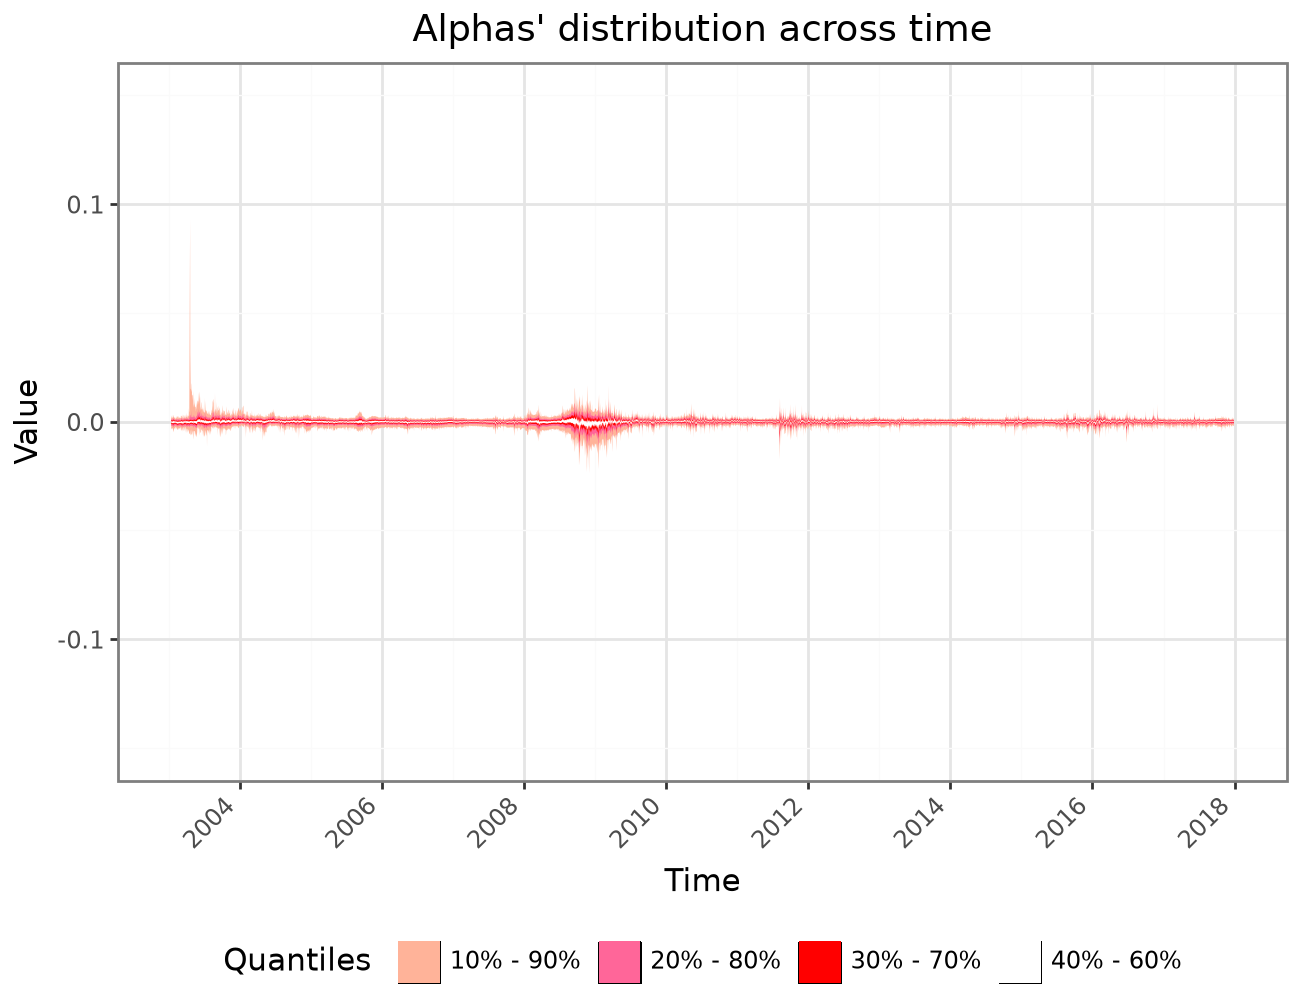

In [ ]:
plot.alphas_river("data/alphas_5min_sc05_t0.parquet", alpha_col = "linear_alpha")

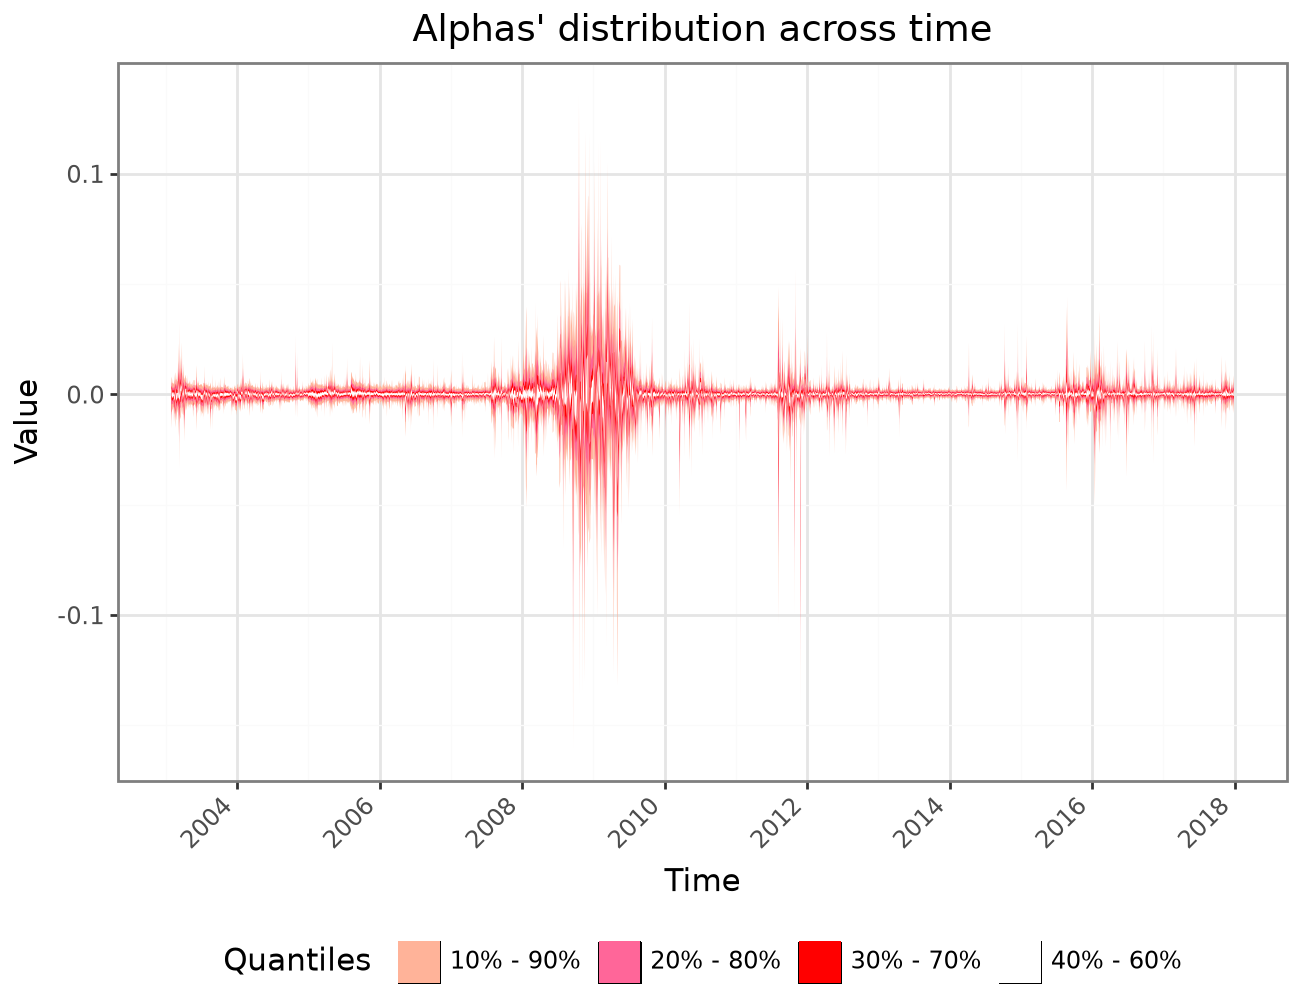

In [ ]:
plot.alphas_river("data/alphas_5min_sc05_t0.parquet", alpha_col = "alpha")

## Appendix

### Saving the results as .mat files

For the rest of the paper's results, MATLAB code is used. Thus, the alphas are saved as .mat files, accompanied by some stock information (volume, market cap) from `data/stocks_raw/PermRetBetas_CRSP_v07.mat`.

This is run for every parameter that was used to calculate the alphas:

In [ ]:
freq = "5min"
scaler = 2

In [ ]:
#| execute: false

permnos = np.load("data/permnos_liquid.npy")
data_betas = pl.scan_parquet(f"data/betas_{freq}.parquet")
data_alphas = pl.scan_parquet(f"data/alphas_{freq}.parquet")
data_adjusted = pl.scan_parquet(f"data/stocks_{freq}_adjusted.parquet")
data_permnos = pl.scan_parquet("data/stocks_1min_returns.parquet")

output1_list = []
output_num_list = []

with h5py.File("data/stocks_raw/PermRetBetas_CRSP_v07.mat", "r") as f:
    # 1. Parse VarNmHead (Cell array of strings)
    VarNmHead = []
    for ref in f["VarNmHead"][:].flatten():
        # MATLAB strings in HDF5 are stored as UTF-16 integer arrays
        # We dereference the object, read the chars, and join them
        var_name = "".join(chr(c[0]) for c in f[ref][:])
        VarNmHead.append(var_name)

    # Apply Correction: VarNmHead{17} = 'Bss5mOC'
    if len(VarNmHead) >= 17:
        VarNmHead[16] = 'Bss5mOC'

    # Map column names to integer indices for fast lookup
    col_idx = {name: idx for idx, name in enumerate(VarNmHead)}


    # 2. Iterate through allPerms
    # In MATLAB, allPerms is (N x 8). In h5py, the shape is transposed to (8 x N).
    #n_stocks = f["allPerms"].shape[1]
    #for i in range(n_stocks):
    permnos_mat = np.array(
        [f[ref][0, 0] for ref in f["allPerms"][0, :]],
        dtype = np.uint32
    )
    for permno in tqdm(permnos):
        i = np.searchsorted(permnos_mat, permno)
        if permno != f[f["allPerms"][0, i]][0, 0]:
            raise ValueError(f"PERMNO {permno} not found in allPerms at index {i}")

        # Extract BetasRets matrix (MATLAB Column 4 -> Python Index 3)
        betas_rets_ref = f["allPerms"][3, i]

        # READ AND TRANSPOSE to convert back to standard row-major matrix
        BetasRets = f[betas_rets_ref][:].T

        # Extract columns using our mapping
        retAsset = BetasRets[:, col_idx['ret']]
        p_close = BetasRets[:, col_idx['p.close']]

        V1 = BetasRets[:, col_idx['prc']]
        V2 = BetasRets[:, col_idx['vol']]
        V3 = BetasRets[:, col_idx['MarketCap']]
        V4 = BetasRets[:, col_idx['t.close']] - BetasRets[:, col_idx['t.open']]
        V5 = BetasRets[:, col_idx['numtrd2']]

        # Get dates:
        data_dates = (
            pl.DataFrame({"date" : BetasRets[:, col_idx['date']].astype(np.int64)})
            .select(
                ts_day_ny = pl.col("date").cast(pl.String).str.to_date("%Y%m%d")
                .dt.epoch("d").cast(pl.UInt32)
            )
        )
        intt = data_dates["ts_day_ny"].to_numpy()# - 719_529

        # Get our betas:
        B = (
            data_dates.join(
                data_betas.filter(pl.col("permno") == permno).collect(),
                on = "ts_day_ny", how = "left"
            )
            .select([f"beta_{i}" for i in range(1, 7)]).to_numpy()
        )

        # Get our resid:
        resid = (
            data_dates.join(
                data_adjusted.filter(pl.col("permno") == permno).collect(),
                on = "ts_day_ny", how = "left"
            )
            ["adjusted_return"].to_numpy()
        )

        # Get our ret* (which is group_by permno,day sum log_return)
        ret = (
            data_permnos
            .filter(pl.col("permno") == permno)
            .group_by(ts_day_ny = pl.col("ts_min_ny")  // (60 * 24))
            .agg(pl.col("log_return").sum())
            .collect()
            .join(data_dates, on = "ts_day_ny", how = "right")
            ["log_return"].to_numpy()
        )

        # Get our condalpha and linalpha:
        alphas = (
            data_dates.join(
                data_alphas.filter(pl.col("permno") == permno).collect(),
                on = "ts_day_ny", how = "left"
            )
            .select(["alpha", "linear_alpha"])
        )
        condalpha = alphas["alpha"].to_numpy()
        linalpha = alphas["linear_alpha"].to_numpy()

        # Reconstruct output arrays (omitting int, resid, condalpha, linalpha as requested)
        # np.column_stack forces 1D arrays into vertical columns side-by-side
        output0 = np.column_stack([intt, B, resid, retAsset, p_close, ret, condalpha, linalpha])
        output00 = np.column_stack([intt, B, V1, V2, V3, V4, V5])

        # Slicing equivalent to MATLAB's (window:end, :)
        out0_sliced = output0[PARS_ALPHAS.window_warmup:, :]
        out00_sliced = output00[PARS_ALPHAS.window_warmup:, :]

        # Append to our tracking lists
        output1_list.append([permno, out0_sliced, out00_sliced])
        output_num_list.append(out0_sliced)


# 3. Format into strict MATLAB-compatible structures
# Create a NumPy "object" array so SciPy saves it as a proper MATLAB Cell Array
output1_cell = np.empty((len(output1_list), 3), dtype=object)
for i, row in enumerate(output1_list):
    output1_cell[i, 0] = row[0]
    output1_cell[i, 1] = row[1]
    output1_cell[i, 2] = row[2]

# Replicate cell2mat(output1(:,2)) by stacking vertically
output_mat = np.vstack(output_num_list)

# 4. Save the outputs
sio.savemat(
    f"data/final/realized_alpha_oos_{freq}_cell_sc{scaler}.mat",
    {"output1": output1_cell}
)
sio.savemat(
    f"data/final/realized_alpha_oos_{freq}_num_sc{scaler}.mat",
    {"output": output_mat}
)

100%|██████████| 1141/1141 [01:23<00:00, 13.67it/s]


### Saving results as a .parquet dataframe

For a more intuitive result, the script below saves the results as a single .parquet dataframe.

In [52]:
def save_alphas(freq, scaler, trim, xi = ""):
    permnos = np.load("data/permnos_liquid.npy")
    xi_text = f"_xi{xi}" if xi else ""
    alpha_path = f"data/alphas/alphas_{freq}_sc{scaler}_t{trim}{xi_text}.parquet"

    # 1. Parse CRSP MATLAB file into a single Polars DataFrame
    crsp_dfs = []
    with h5py.File("data/stocks_raw/PermRetBetas_CRSP_v07.mat", "r") as f:
        VarNmHead = ["".join(chr(c[0]) for c in f[ref][:]) for ref in f["VarNmHead"][:].flatten()]
        if len(VarNmHead) >= 17:
            VarNmHead[16] = 'Bss5mOC'
        col_idx = {name: idx for idx, name in enumerate(VarNmHead)}

        permnos_mat = np.array([f[ref][0, 0] for ref in f["allPerms"][0, :]], dtype=np.uint32)

        for permno in permnos:
            i = np.searchsorted(permnos_mat, permno)
            if permno != f[f["allPerms"][0, i]][0, 0]:
                raise ValueError(f"PERMNO {permno} not found in allPerms at index {i}")

            BetasRets = f[f["allPerms"][3, i]][:].T

            df_p = pl.DataFrame({
                "permno": np.uint32(permno),
                "date_raw": BetasRets[:, col_idx['date']].astype(np.int64).astype(str),
                "ret_asset": BetasRets[:, col_idx['ret']],
                "p_close": BetasRets[:, col_idx['p.close']],
                "prc": BetasRets[:, col_idx['prc']],
                "vol": BetasRets[:, col_idx['vol']],
                "mcap": BetasRets[:, col_idx['MarketCap']],
                "duration": BetasRets[:, col_idx['t.close']] - BetasRets[:, col_idx['t.open']],
                "numtrd": BetasRets[:, col_idx['numtrd2']],
            }).with_columns(
                ts_day_ny=pl.col("date_raw").str.to_date("%Y%m%d").dt.epoch("d").cast(pl.UInt32)
            ).drop("date_raw")

            crsp_dfs.append(df_p)

    df_crsp = pl.concat(crsp_dfs).lazy()

    # 2. Batch load auxiliary Parquet datasets
    #df_betas = (
    #    pl.scan_parquet(f"data/betas_{freq}.parquet")
    #    .filter(pl.col("permno").is_in(permnos))
    #)

    df_alphas = (
        pl.scan_parquet(alpha_path)
        .filter(pl.col("permno").is_in(permnos))
        .select(["permno", "ts_day_ny", "linear_alpha", "alpha"])
        .rename({"linear_alpha": "alpha_linear", "alpha": "alpha_kernel"})
    )

    #df_adjusted = (
    #    pl.scan_parquet(f"data/stocks_{freq}_adjusted.parquet")
    #    .filter(pl.col("permno").is_in(permnos))
    #    .select(["permno", "ts_day_ny", "adjusted_return"])
    #    .rename({"adjusted_return": "adj_return"})
    #)

    #df_returns = (
    #    pl.scan_parquet("data/stocks_1min_returns.parquet")
    #    .filter(pl.col("permno").is_in(permnos))
    #    .group_by(
    #        permno=pl.col("permno"),
    #        ts_day_ny=pl.col("ts_min_ny") // (60 * 24)
    #    )
    #    .agg(ret_log=pl.col("log_return").sum())
    #)

    # 3. Join all features into one main DataFrame
    df_final = (
        df_crsp
        #.join(df_betas, on=["permno", "ts_day_ny"], how="left")
        .join(df_alphas, on=["permno", "ts_day_ny"], how="left")
        #.join(df_adjusted, on=["permno", "ts_day_ny"], how="left")
        #.join(df_returns, on=["permno", "ts_day_ny"], how="left")
        #.filter(pl.int_range(0, pl.len()).over("permno") >= PARS_ALPHAS.window_warmup)
        .sort(["permno", "ts_day_ny"])
    )

    # 5. Order and select final columns
    columns_order = [
        "permno", "ts_day_ny",
        #"beta_1", "beta_2", "beta_3", "beta_4", "beta_5", "beta_6",
        "alpha_linear", "alpha_kernel",
        "ret_asset", #"ret_log", "adj_return",
        "p_close", "prc", "vol", "mcap", "duration", "numtrd"
    ]

    df_final = df_final.select(columns_order)

    # 6. Export to Parquet
    df_final.sink_parquet(f"data/portfolios/port_{freq}_sc{scaler}_t{trim}{xi_text}.parquet")

In [53]:
args = [
    {"freq": "5min", "scaler": "05", "trim_option": "ln2", "xi": "025"},
    {"freq": "5min", "scaler": 1, "trim_option": "ln2", "xi": "025"},
    {"freq": "5min", "scaler": 2, "trim_option": "ln2", "xi": "025"},
    #{"freq": "5min", "scaler": "05", "trim_option": "0"},
    #{"freq": "5min", "scaler": 1, "trim_option": "0"},
    #{"freq": "5min", "scaler": 2, "trim_option": "0"},
    #{"freq": "5min", "scaler": "05", "trim_option": "ln2"},
    #{"freq": "5min", "scaler": 1, "trim_option": "ln2"},
    #{"freq": "5min", "scaler": 2, "trim_option": "ln2"}
]

for arg in args:
    save_alphas(arg["freq"], arg["scaler"], arg["trim_option"], arg.get("xi", ""))

Saving just the stock return info:

In [4]:
permnos = np.load("data/permnos_liquid.npy")

crsp_dfs = []
with h5py.File("data/stocks_raw/PermRetBetas_CRSP_v07.mat", "r") as f:
    VarNmHead = ["".join(chr(c[0]) for c in f[ref][:]) for ref in f["VarNmHead"][:].flatten()]
    if len(VarNmHead) >= 17:
        VarNmHead[16] = 'Bss5mOC'
    col_idx = {name: idx for idx, name in enumerate(VarNmHead)}

    permnos_mat = np.array([f[ref][0, 0] for ref in f["allPerms"][0, :]], dtype=np.uint32)

    for permno in permnos:
        i = np.searchsorted(permnos_mat, permno)
        if permno != f[f["allPerms"][0, i]][0, 0]:
            raise ValueError(f"PERMNO {permno} not found in allPerms at index {i}")

        BetasRets = f[f["allPerms"][3, i]][:].T

        df_p = (
            pl.DataFrame({
                "permno": np.uint32(permno),
                "date_raw": BetasRets[:, col_idx['date']].astype(np.int64).astype(str),
                "ret_asset": BetasRets[:, col_idx['ret']],
            })
            .with_columns(
                ts_day_ny=pl.col("date_raw").str.to_date("%Y%m%d").dt.epoch("d").cast(pl.UInt32)
            )
            .drop("date_raw")
            .sort(["permno", "ts_day_ny"])
        )

        crsp_dfs.append(df_p)

df_crsp = pl.concat(crsp_dfs)

df_crsp.write_parquet("data/stocks_raw/stock_returns.parquet")